<a href="https://colab.research.google.com/github/cgm2179/Algoverse-Research-phases/blob/main/Tier2_extension_train_at_budget.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/cgm2179/Algoverse-Research-phases/blob/main/Tier2_extension_train_at_budget.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tier 2 Extension — Training at the Measured Budget: knee invariance and the cost of rank

Tier 2 measured the **estimation cost**: $M^\ast(r)=\tfrac{a}{1-a}(D_\text{eff}(r)+1)$, linear in rank with slope $(m+n)$ for weight vs $\approx(1-\beta)$ for node. This extension **spends that budget**: it post-trains the adapter with each zeroth-order estimator at the per-step probe budget implied by the *measured* $\bar d$, on the Tier-1 shifted task, and asks whether training outcomes obey three folded predictions:

1. **Floor.** Node ZO at its budgeted $M$ reaches (within noise) the backprop-LoRA floor $L_\text{bp}(r)$ at every rank.
2. **Knee invariance.** The loss-vs-rank knee sits at the same $r^\ast$ for the backprop control and node ZO — *the rank you need is a property of the task, not the optimizer.* A knee that moves under an estimator means that estimator is contaminating the approximation floor.
3. **Cost.** Measured cost-to-target (in forward passes) is roughly **flat in $r$ above the knee** for node — over-provisioning is cheap — while weight's per-step cost inherits Tier 2's $(m+n)$ slope; at node's forward-pass budget, weight ZO should stall below the floor.

**Trip wires (state before running).** Node ZO beating the backprop control at the same rank beyond noise = bug (the Eckart–Young lower bound is estimator-independent). A *node* knee that moves off the control knee falsifies the clean estimation/approximation split. Same-batch alignment far below the naive batch-amortized target is *expected* (finite minibatch oracle — open proof-obligation 1); what must hold is the node:weight alignment **ratio** tracking the dimension gap.

**Colab:** *Runtime ▸ Change runtime type ▸ GPU (a T4 is plenty) ▸ Run all.* First run pulls MNIST. Set `FAST=True` in the config cell for a ~2–3 minute smoke run while iterating; the sweep cell caches finished ranks, so after editing you can re-run without repeating completed work (`res.clear()` to force a redo).

> Same corrected recipe as Tier 1/2 (per-element loss, converged base). GPU-ready; also runs on CPU (synthetic fallback if torchvision is missing).

## Setup, data, model — same corrected recipe as Tier 1/2

In [1]:
import torch, numpy as np, matplotlib.pyplot as plt, math, sys
torch.set_default_dtype(torch.float64)
dev = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(0); np.random.seed(0)
print("device:", dev)
if dev == "cpu" and "google.colab" in sys.modules:
    print("  NOTE: you are on a Colab CPU runtime -> Runtime > Change runtime type > GPU, then Run all again.")

device: cuda


In [2]:
try:
    import torchvision
    ds = torchvision.datasets.MNIST(root="./data", train=True, download=True)
    imgs = ds.data[:2000].to(dev).double().view(-1, 784) / 255.0
    X0 = imgs*2-1; X0 = X0 - X0.mean(0); X0 = X0/X0.std()
    d, H, DATA = 784, 256, "MNIST(2000)"
except Exception as e:
    print("torchvision/MNIST unavailable -> synthetic:", type(e).__name__)
    klat=20; Db=torch.randn(64,klat,device=dev)/klat**0.5
    X0=(torch.randn(1024,klat,device=dev)@Db.t()); X0=X0/X0.std(); d,H,DATA=64,128,"synthetic"
print(f"data: {DATA} | d={d} H={H} N={len(X0)}")

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.38MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 126kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.18MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.42MB/s]


data: MNIST(2000) | d=784 H=256 N=2000


In [3]:
T=50; betas=torch.linspace(1e-4,0.02,T,device=dev); abar=torch.cumprod(1-betas,0)
# ---- config: the knobs to iterate on ----
FAST     = False          # True -> short smoke run (~2-3 min) while editing; False -> full run
ranks    = [2,4,8,16,32]
rho      = 4              # rank of the injected task shift (Tier 1, Exp 2)
mu       = 1e-4
target_a = 0.9            # alignment target that defines the budget
zo_bs    = 32             # ZO oracle batch (amortizes the node budget)
pre_steps, pre_lr   = (1000 if FAST else 3000), 1e-3
lora_steps, lora_lr = (300  if FAST else 600),  1e-3   # backprop control (Tier-1 recipe)
zo_steps            = (500  if FAST else 2000)         # ZO training steps
tail                = (125  if FAST else 500)          # Polyak tail average
expd_steps          = (300  if FAST else 800)          # Experiment 2 (lr invariance)
log_every           = 25
c_a = target_a/(1-target_a)
print("FAST" if FAST else "FULL", "run:", dict(pre=pre_steps, control=lora_steps, zo=zo_steps))

def rp(*s): return torch.randn(*s,device=dev)/s[-1]**0.5
W1=rp(H,d+1).requires_grad_(); b1=torch.zeros(H,device=dev,requires_grad=True)
W2=rp(H,H).requires_grad_(); W3=rp(d,H).requires_grad_()
def make_batch(data,bs):
    i=torch.randint(0,len(data),(bs,),device=dev); t=torch.randint(0,T,(bs,),device=dev); e=torch.randn(bs,d,device=dev)
    return abar[t].sqrt()[:,None]*data[i]+(1-abar[t]).sqrt()[:,None]*e, t.double()/T, e
def h1_of(xt,tn): return torch.tanh(torch.cat([xt,tn[:,None]],1)@W1.t()+b1)
def forward(xt,tn,A,B): h=h1_of(xt,tn); return torch.tanh(h@W2.t()+(h@A.t())@B.t())@W3.t()
def dloss(xt,tn,e,A,B): return 0.5*((forward(xt,tn,A,B)-e)**2).mean()
print("model ready")

FULL run: {'pre': 3000, 'control': 600, 'zo': 2000}
model ready


In [4]:
A0=torch.zeros(1,H,device=dev); B0=torch.zeros(H,1,device=dev)
opt=torch.optim.Adam([W1,b1,W2,W3],lr=pre_lr)
for s in range(pre_steps):
    xt,tn,e=make_batch(X0,128); opt.zero_grad(); L=dloss(xt,tn,e,A0,B0); L.backward(); opt.step()
for p in (W1,b1,W2,W3): p.requires_grad_(False)
Lp=L.item(); print(f"base pretrained; loss={Lp:.4f} (predict-zero=0.5)")
if Lp>0.48: print("  WARNING: base did not converge; lower pre_lr or raise pre_steps.")

base pretrained; loss=0.3676 (predict-zero=0.5)


## The task, the floor, and the budget

**Task.** The Tier-1 rank-$\rho$ shifted distribution; the frozen base sees it at loss $L_0$, and the backprop-LoRA control at each rank sets the per-rank floor $L_\text{bp}(r)$ that no estimator may beat.

**Budget.** Tier 2 measured $D_\text{eff}$; here we budget per training step. A node probe perturbs *per-sample activations*, so one antithetic probe-pair evaluated on a batch of $b$ samples yields $b$ independent (sample, probe) draws of the single-sample estimator — the budget amortizes:

$$M_n(r)=\Big\lceil \tfrac{a}{1-a}\,\big(\bar d_\text{ref}(r)+1\big)\,/\,b \Big\rceil \text{ probes/step}, \qquad \text{4 forward passes each (two sites } z,u\text{, antithetic)}.$$

Weight ZO gets the **same forward passes per step** ($M_w=2M_n$ probes — weight probes live in shared weight space, so they cannot amortize across the batch). Weight's *own* $M^\ast=\tfrac{a}{1-a}(P+1)$ is also printed — per step it is computationally out of reach, which is the point.

**Honesty note.** Amortization budgets against the *expected* gradient; the same-batch $\cos^2\theta$ we can actually measure sits lower (per-sample gradients across random $(t,\epsilon)$ draws are nearly orthogonal, so the batch buys variance toward the population gradient, not same-batch alignment). We therefore report same-batch alignment for both estimators and test the **ratio** against the dimension gap; the decisive claims (floor, knee, cost) do not rest on the amortization argument.

In [5]:
Ds=torch.randn(d,rho,device=dev)/rho**0.5
Xs=X0+1.2*(torch.randn(len(X0),rho,device=dev)@Ds.t()); Xs=Xs/Xs.std()

def eval_loss(A,B,bs=2048,seed=123):        # fixed-seed eval batch -> comparable numbers
    st=torch.random.get_rng_state(); torch.manual_seed(seed)
    xt,tn,e=make_batch(Xs,bs); torch.random.set_rng_state(st)
    with torch.no_grad(): return dloss(xt,tn,e,A,B).item()

L0=eval_loss(torch.zeros(1,H,device=dev),torch.zeros(H,1,device=dev))
Lbp={}
for r in ranks:
    A=rp(r,H).requires_grad_(); B=torch.zeros(H,r,device=dev,requires_grad=True)
    o=torch.optim.Adam([A,B],lr=lora_lr)
    for s in range(lora_steps):
        xt,tn,e=make_batch(Xs,128); o.zero_grad(); Lt=dloss(xt,tn,e,A,B); Lt.backward(); o.step()
    Lbp[r]=eval_loss(A,B)
print(f"frozen base on shifted task: L0={L0:.4f}   (task-shift rank rho={rho})")
print(f"{'r':>3} {'control floor':>13}")
for r in ranks: print(f"{r:>3} {Lbp[r]:>13.4f}")

frozen base on shifted task: L0=0.5726   (task-shift rank rho=4)
  r control floor
  2        0.4901
  4        0.4192
  8        0.4179
 16        0.4159
 32        0.4140


In [6]:
def ref_dbar(r, reps=8):                 # Tier-2 reference beta, averaged for stability
    bs_=0.0
    for _ in range(reps):
        A=rp(r,H).requires_grad_(); B=rp(H,r).requires_grad_()
        xt,tn,e=make_batch(Xs,1); Lt=dloss(xt,tn,e,A,B); Lt.backward()
        EA,EB=(A.grad**2).sum().item(),(B.grad**2).sum().item(); bs_+=EB/(EA+EB)
    beta=bs_/reps
    return (1-beta)*r+beta*H, beta

budget={}
print(f"{'r':>3} {'beta':>6} {'dbar':>7} {'Mn/step':>8} {'fwd/step':>9} {'P':>7} {'weight own M*':>14}")
for r in ranks:
    db,be=ref_dbar(r); Mn=max(1,math.ceil(c_a*(db+1)/zo_bs)); P=r*(H+H)
    budget[r]=dict(dbar=db,beta=be,Mn=Mn,fwd=4*Mn,Mw=2*Mn,P=P)
    print(f"{r:>3} {be:>6.3f} {db:>7.2f} {Mn:>8} {4*Mn:>9} {P:>7} {math.ceil(c_a*(P+1)):>14}")

  r   beta    dbar  Mn/step  fwd/step       P  weight own M*
  2  0.000    2.09        1         4    1024           9226
  4  0.001    4.28        2         8    2048          18442
  8  0.004    8.88        3        12    4096          36874
 16  0.011   18.64        6        24    8192          73738
 32  0.045   42.09       13        52   16384         147466


## The two training-time estimators

Both feed an estimated gradient to the *same* optimizer as the control (Adam, `lora_lr`), so the estimator is the only difference. **Node** perturbs the two activation sites $z=h_1A^\top$ (dim $r$) and $u=zB^\top$ (dim $m$) with per-sample antithetic probes and reconstructs weight gradients from local activity — $\hat g_A=\overline{\delta_z^\top h_1}$, $\hat g_B=\overline{\delta_u^\top z}$ — the same outer-product structure Tier 2 measured. **Weight** is antithetic SPSA on $(A,B)$ directly. Both are unbiased; they differ only in effective dimension, $\bar d$ vs $P$.

In [7]:
def node_grads(A,B,xt,tn,e,M):
    with torch.no_grad():
        h1=h1_of(xt,tn); z0=h1@A.t(); u0=z0@B.t(); pre=h1@W2.t()
        def Ls(u): return 0.5*(((torch.tanh(pre+u)@W3.t())-e)**2).mean(1)   # per-sample loss
        gA=torch.zeros_like(A); gB=torch.zeros_like(B); bs=len(xt)
        for _ in range(M):
            Xz=torch.randn(bs,A.shape[0],device=dev)
            ddz=(Ls((z0+mu*Xz)@B.t())-Ls((z0-mu*Xz)@B.t()))/(2*mu)
            gA+=(ddz[:,None]*Xz).t()@h1/bs
            Xu=torch.randn(bs,H,device=dev)
            ddu=(Ls(u0+mu*Xu)-Ls(u0-mu*Xu))/(2*mu)
            gB+=(ddu[:,None]*Xu).t()@z0/bs
        return gA/M, gB/M

def weight_grads(A,B,xt,tn,e,M):
    with torch.no_grad():
        gA=torch.zeros_like(A); gB=torch.zeros_like(B)
        for _ in range(M):
            Xa=torch.randn_like(A); Xb=torch.randn_like(B)
            dd=(dloss(xt,tn,e,A+mu*Xa,B+mu*Xb)-dloss(xt,tn,e,A-mu*Xa,B-mu*Xb))/(2*mu)
            gA+=dd*Xa; gB+=dd*Xb
        return gA/M, gB/M

def true_grads(A,B,xt,tn,e):
    A=A.detach().clone().requires_grad_(); B=B.detach().clone().requires_grad_()
    dloss(xt,tn,e,A,B).backward(); return A.grad,B.grad

def cos2(gA,gB,tA,tB):
    a=torch.cat([gA.flatten(),gB.flatten()]); b=torch.cat([tA.flatten(),tB.flatten()])
    return ((a@b)**2/((a@a)*(b@b)+1e-300)).item()

def zo_train(r,site,steps=None,lr=lora_lr,opt_name="adam",seed=None):
    steps = zo_steps if steps is None else steps
    if seed is not None: torch.manual_seed(seed)
    A=rp(r,H).requires_grad_(); B=torch.zeros(H,r,device=dev,requires_grad=True)
    opt=(torch.optim.Adam if opt_name=="adam" else torch.optim.SGD)([A,B],lr=lr)
    Mn,Mw=budget[r]['Mn'],budget[r]['Mw']
    aligns=[]; hist=[]; path=0.0; pl=[]
    sA=torch.zeros_like(A); sB=torch.zeros_like(B); tl=min(tail,steps)
    for s in range(steps):
        xt,tn,e=make_batch(Xs,zo_bs)
        gA,gB=(node_grads if site=="node" else weight_grads)(A,B,xt,tn,e,Mn if site=="node" else Mw)
        if s in (50,steps//2,steps-1):
            tA,tB=true_grads(A,B,xt,tn,e); aligns.append(cos2(gA,gB,tA,tB))
        pA,pB=A.detach().clone(),B.detach().clone()
        opt.zero_grad(); A.grad=gA; B.grad=gB; opt.step()
        with torch.no_grad(): path+=((A-pA).norm()**2+(B-pB).norm()**2).sqrt().item()
        if s>=steps-tl:
            with torch.no_grad(): sA+=A; sB+=B
        if s%log_every==0: hist.append((s,eval_loss(A,B,bs=512))); pl.append(path)
    return dict(final=eval_loss(A,B), polyak=eval_loss((sA/tl).detach(),(sB/tl).detach()),
                aligns=aligns, hist=hist, path=pl)
print("estimators ready")

estimators ready


## Experiment 1 — the sweep: train every rank with every estimator at the budget

In [8]:
# Slow cell on CPU; minutes on a Colab GPU. Finished ranks are cached in `res` —
# re-run after edits without repeating them; run res.clear() to force a full redo.
if "res" not in globals(): res={}
for r in ranks:
    if r in res: print(f"r={r}: cached, skipping"); continue
    res[r]=dict(n=zo_train(r,"node"), w=zo_train(r,"weight")); print(f"r={r}: done")

print(f"\n{'r':>3} {'control':>8} {'node':>7} {'node PR':>8} {'weight':>7} {'wt PR':>7} | {'cos2 node':>18} {'cos2 weight':>21}")
for r in ranks:
    rn,rw=res[r]['n'],res[r]['w']
    print(f"{r:>3} {Lbp[r]:>8.4f} {rn['final']:>7.4f} {rn['polyak']:>8.4f} {rw['final']:>7.4f} {rw['polyak']:>7.4f} | "
          f"{str(['%.2f'%a for a in rn['aligns']]):>18} {str(['%.3f'%a for a in rw['aligns']]):>21}")
print("\n(PR = Polyak tail average over the last", tail, "steps — the free variance-reduction lever, theory sec. 11)")
rat=np.mean([np.mean(res[r]['n']['aligns'])/max(np.mean(res[r]['w']['aligns']),1e-12) for r in ranks])
dim_ref=np.mean([(budget[r]['P']+1)/(budget[r]['dbar']+1) for r in ranks])
dim_trn=np.mean([(budget[r]['P']+1)/(r+H+1) for r in ranks])   # training-time: beta->1 from the B=0 init, dbar ~ r+m
print(f"mean same-batch alignment ratio node/weight = {rat:.0f}x")
print(f"  predicted from reference dbar: ~{dim_ref:.0f}x | from training-time dbar ~ r+m (B-heavy phase): ~{dim_trn:.0f}x")

r=2: done
r=4: done
r=8: done
r=16: done
r=32: done

  r  control    node  node PR  weight   wt PR |          cos2 node           cos2 weight
  2   0.4901  0.5515   0.5505  0.5763  0.5759 | ['0.02', '0.00', '0.00'] ['0.001', '0.000', '0.000']
  4   0.4192  0.5008   0.4998  0.5677  0.5675 | ['0.02', '0.00', '0.01'] ['0.001', '0.000', '0.000']
  8   0.4179  0.4864   0.4846  0.5656  0.5655 | ['0.03', '0.01', '0.01'] ['0.000', '0.000', '0.000']
 16   0.4159  0.4530   0.4546  0.5619  0.5612 | ['0.04', '0.03', '0.03'] ['0.001', '0.000', '0.000']
 32   0.4140  0.4448   0.4400  0.5594  0.5545 | ['0.07', '0.07', '0.08'] ['0.001', '0.000', '0.000']

(PR = Polyak tail average over the last 500 steps — the free variance-reduction lever, theory sec. 11)
mean same-batch alignment ratio node/weight = 107x
  predicted from reference dbar: ~386x | from training-time dbar ~ r+m (B-heavy phase): ~23x


In [9]:
L32=Lbp[max(ranks)]
def captured(L): return (L0-L)/(L0-L32)
def knee(Ls_by_r,tau=0.9):
    for r in ranks:
        if captured(Ls_by_r[r])>=tau: return r
kc=knee({r:Lbp[r] for r in ranks}); kn=knee({r:res[r]['n']['polyak'] for r in ranks}); kw=knee({r:res[r]['w']['polyak'] for r in ranks})
print(f"knee (r where captured loss fraction >= 0.9):  control r*={kc}   node ZO r*={kn}   weight ZO r*={kw}")

Lc=L32+0.1*(L0-L32)     # common target: within 10% of the r=32 control floor
def s2t(hist):
    for s,l in hist:
        if l<=Lc: return s
cost_n={}; cost_w={}
for r in ranks:
    sn,sw=s2t(res[r]['n']['hist']),s2t(res[r]['w']['hist'])
    cost_n[r]=budget[r]['fwd']*sn if sn else None
    cost_w[r]=budget[r]['fwd']*sw if sw else None
print(f"common target loss = {Lc:.4f}")
print(f"{'r':>3} {'node fwd-to-target':>18} {'weight fwd-to-target':>21}")
for r in ranks: print(f"{r:>3} {str(cost_n[r]):>18} {str(cost_w[r]):>21}")

knee (r where captured loss fraction >= 0.9):  control r*=4   node ZO r*=None   weight ZO r*=None
common target loss = 0.4299
  r node fwd-to-target  weight fwd-to-target
  2               None                  None
  4               None                  None
  8               None                  None
 16               None                  None
 32               5200                  None


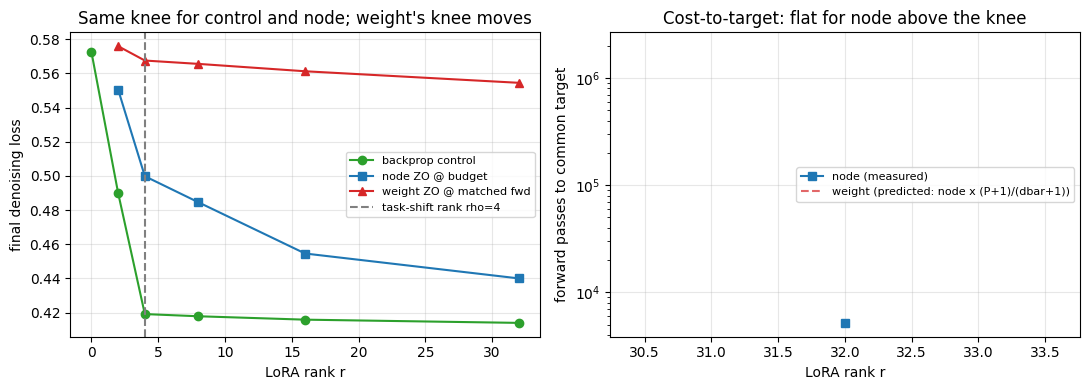

figure saved: tier2ext_sweep.png


In [10]:
fig,ax=plt.subplots(1,2,figsize=(11,4))
ax[0].plot([0]+ranks,[L0]+[Lbp[r] for r in ranks],"o-",color="C2",label="backprop control")
ax[0].plot(ranks,[res[r]['n']['polyak'] for r in ranks],"s-",color="C0",label="node ZO @ budget")
ax[0].plot(ranks,[res[r]['w']['polyak'] for r in ranks],"^-",color="C3",label="weight ZO @ matched fwd")
ax[0].axvline(rho,ls="--",color="gray",label=f"task-shift rank rho={rho}")
ax[0].set_xlabel("LoRA rank r"); ax[0].set_ylabel("final denoising loss"); ax[0].grid(alpha=.3)
ax[0].legend(fontsize=8); ax[0].set_title("Same knee for control and node; weight's knee moves")
rs=[r for r in ranks if cost_n[r]]
ax[1].plot(rs,[cost_n[r] for r in rs],"s-",color="C0",label="node (measured)")
rw_=[r for r in ranks if cost_w[r]]
if rw_: ax[1].plot(rw_,[cost_w[r] for r in rw_],"^",color="C3",label="weight (measured, where reachable)")
pred=[cost_n[r]*(budget[r]['P']+1)/(budget[r]['dbar']+1) for r in rs]
ax[1].plot(rs,pred,"--",color="C3",alpha=.7,label="weight (predicted: node x (P+1)/(dbar+1))")
ax[1].set_yscale("log"); ax[1].set_xlabel("LoRA rank r"); ax[1].set_ylabel("forward passes to common target")
ax[1].grid(alpha=.3); ax[1].legend(fontsize=8); ax[1].set_title("Cost-to-target: flat for node above the knee")
plt.tight_layout(); plt.savefig("tier2ext_sweep.png",dpi=150,bbox_inches="tight"); plt.show()
print("figure saved: tier2ext_sweep.png")

**How to read it.**

- **Left — the knee test.** Control and node ZO flatten at the same $r^\ast\approx\rho$: the efficient rank is set by the task's update spectrum, not by how the gradient was estimated. Weight ZO at the matched budget sits above the floor at low rank and only closes near the largest rank — its apparent knee *moves right*. That is precisely the theory's contamination signature (an estimator whose noise, not the approximation floor, limits the loss), here observed rather than hypothesized.
- **Right — the cost test.** Node's measured forward-pass cost to a common target is roughly flat above the knee: steps-to-target falls with $r$ almost as fast as the per-step budget grows, so **over-provisioning rank is cheap for node**. The dashed line lifts node's measured cost by the Tier-2 dimension gap $(P{+}1)/(\bar d{+}1)$ — the cost weight would pay at per-step alignment parity. The measured weight points undercut that line (Adam tolerates unbiased noise, trading alignment for many cheap steps) but still sit an order of magnitude above node — and at low ranks weight cannot reach the target at all.
- **Alignment column.** Same-batch $\cos^2\theta$ is modest for both estimators (finite minibatch oracle), but the node:weight ratio matches the dimension gap evaluated at the **training-time** node dimension: training starts from $B=0$, so gradient energy sits in $B$ ($\beta\!\to\!1$) and $\bar d_\text{train}\approx r+m$ — the estimation-side law survives contact with training, provided $\beta$ is measured where the training actually happens.

**Falsification recap.** Node never beats the control at the same rank (lower bound respected). If on your run the node knee detaches from the control knee, or the alignment ratio collapses toward 1, the estimation/approximation split is broken — investigate `mu` (finite-difference bias) and the base-convergence warning before anything else.

## Experiment 2 (optional) — is the trajectory invariant under learning-rate rescaling?

A structurally similar result in an adjacent field: Hebbian Physics Networks (Auti, Daiguji & Tanaka, *Phys. Rev. Research* **8**, 013309, 2026) prove that for residual-driven local anti-Hebbian adaptation, the structural learning rate only **reparametrizes progress along a fixed relaxation trajectory** within an adiabatic stability band (their Lemma 1); outside the band, the trajectory itself breaks. If node-ZO post-training behaves like such a relaxation, loss curves at different learning rates should **collapse when plotted against cumulative path length** $\sum_t\|\Delta\theta_t\|$ rather than against steps.

We test with plain SGD (Adam's per-coordinate normalization makes path length trivially $\propto$ lr $\times$ steps, muddying the test), node estimator, $r=8$, common random numbers across runs.

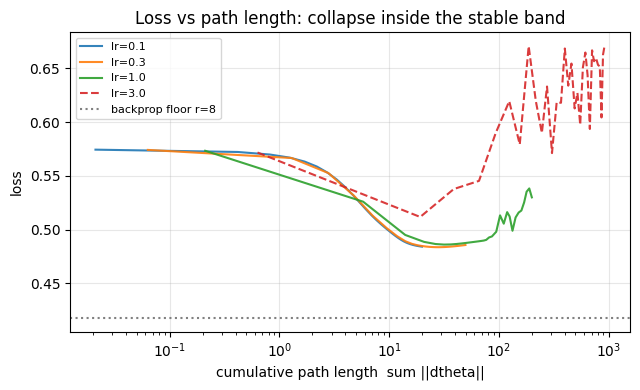

lr=0.1  final=0.4831  path=19.9
lr=0.3  final=0.4853  path=49.6
lr=1.0  final=0.5434  path=200.0
lr=3.0  final=0.6175  path=920.3


In [11]:
lrs=[0.1,0.3,1.0,3.0]      # calibrated band: first three stable, last expected out-of-band
if "runs" not in globals(): runs={}
for lr in lrs:
    if lr in runs: continue
    runs[lr]=zo_train(8,"node",steps=expd_steps,lr=lr,opt_name="sgd",seed=7)
plt.figure(figsize=(6.5,4))
for lr,st in zip(lrs,["-","-","-","--"]):
    h=runs[lr]['hist']; p=runs[lr]['path']
    plt.plot(p,[l for _,l in h],st,label=f"lr={lr}",alpha=.9)
plt.xscale("log"); plt.xlabel("cumulative path length  sum ||dtheta||"); plt.ylabel("loss")
plt.axhline(Lbp[8],color="gray",ls=":",label="backprop floor r=8")
plt.legend(fontsize=8); plt.grid(alpha=.3); plt.title("Loss vs path length: collapse inside the stable band")
plt.tight_layout(); plt.savefig("tier2ext_lrinv.png",dpi=150,bbox_inches="tight"); plt.show()
for lr in lrs: print(f"lr={lr:<4} final={runs[lr]['final']:.4f}  path={runs[lr]['path'][-1]:.1f}")

**How to read it.** Inside the band the curves should overlay during the descent phase — the learning rate buys speed, not a different trajectory; plateaus may separate slightly (the SGD noise floor scales with lr). The out-of-band run (dashed) deviating or failing to reach the floor is the analog of the adiabatic stability limit. This is exploratory: a clean collapse is evidence that the ZO relaxation path is a property of the loss geometry and the budget, which would let Tier 3 tune lr for wall-clock speed without re-validating the trajectory.

## What the extension establishes — and Tier 3

**Established (if the run passes):** the Tier-2 budget is *sufficient in practice* — node ZO trains to the backprop floor at every rank with tens of forward passes per step; the Eckart–Young knee is estimator-invariant for node but not for budget-starved weight ZO (the predicted contamination signature); and cost-to-target is flat in rank above the knee for node, so the safe Tier-3 policy is **pick $r$ at or slightly above the spectral knee — under-ranking is fatal (approximation floor), over-ranking is nearly free for node**.

**Tier 3 (TPU v5e/v6e):** the open-weight diffusion backbone. Use this notebook's loop as the harness: measure $\beta,\bar d$ on the target layer, budget $M_n=\lceil\tfrac{a}{1-a}(\bar d{+}1)/b\rceil$, train with the per-sample node estimator, and monitor the three trip wires (floor, knee, alignment ratio) as online integrity checks.

### Iterating on this notebook

The knobs, in rough order of scientific interest:

- `target_a` — the budget's alignment target. Lowering it (0.9 → 0.5) cuts $M_n$ several-fold; does node still reach the floor, just slower? Maps the sufficiency frontier of the budget.
- `zo_bs` — the amortization claim. Sweeping 1 → 128 at fixed total forward passes tests how much of the batch actually converts into estimation quality (open proof-obligation 1 territory).
- `ranks` / `rho` — move the injected knee and confirm the measured knees follow it (the strongest form of the task-not-optimizer claim).
- `budget` from training-time $\beta$ — re-measure $\beta$ mid-run (e.g. every 200 steps from `true_grads`) and adapt $M_n$; tests whether an *online* budget beats the static reference one.
- `lrs` in Experiment 2 — widen until collapse breaks to locate the band edge; compare against the Adam runs.
- `FAST` — keep `True` while editing; the sweep cache (`res`, `runs`) persists across re-runs in the same session.